In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
import time
import copy

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Rectangle, Circle
from matplotlib.ticker import FormatStrFormatter
import tomlkit

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import cupy as cp
cp.cuda.Device(7).use()

import warnings
warnings.filterwarnings("ignore")

import esc_llowfsc_sim
from esc_llowfsc_sim.math_module import xp, xcipy, ensure_np_array
from esc_llowfsc_sim import utils, wfe, props, source_flux, detector, shmim_utils
import esc_llowfsc_sim.esc_fraunhofer as esc

from magpyx.utils import ImageStream

model_path = esc_llowfsc_sim.path/'data/2k-256/'
# model_path = esc_llowfsc_sim.path/'data/1k-256/'

with open(model_path/'model_params.toml', mode="r",) as fp:
    params = tomlkit.load(fp).unwrap()
model_params = params['model']

# model_params.update({
#     'camlo_pxscl':4.6e-6,
#     'llowfsc_defocus':2e-3,
# })

/opt/conda/envs/llowfscSim310/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Total flux over bandpass = 9.273e+09 ph / (s m2)


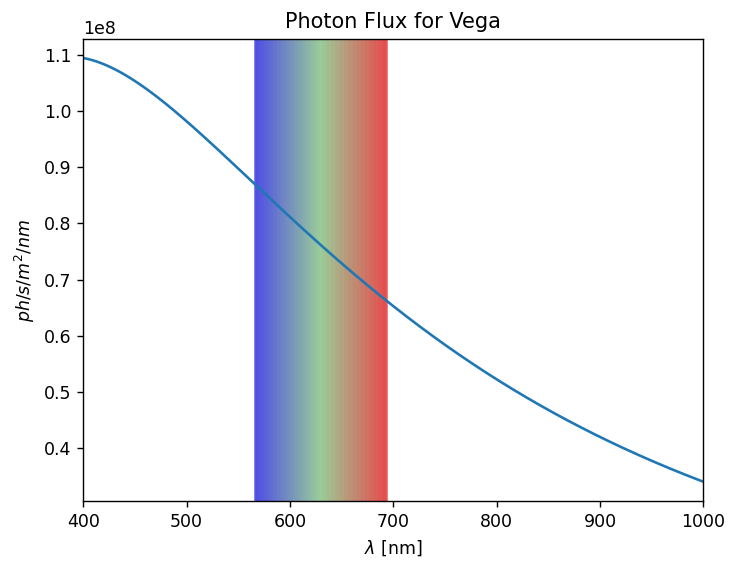

In [2]:
Nwaves = 101
bw = 0.20
waves = np.linspace(model_params['wavelength_c']*(1 - bw/2), model_params['wavelength_c']*(1 + bw/2), Nwaves)

mag0_source_params = source_flux.mag0_source_params
mag0_source_params.update({'wavelengths':waves})
mag0_source = source_flux.SOURCE(**mag0_source_params)
mag0_source.plot_spectrum_ph()
mag0_flux_per_wave = mag0_source.calc_fluxes()
mag0_total_ep_flux = np.sum(mag0_flux_per_wave)
print(f'Total flux over bandpass = {mag0_total_ep_flux:.3e}')

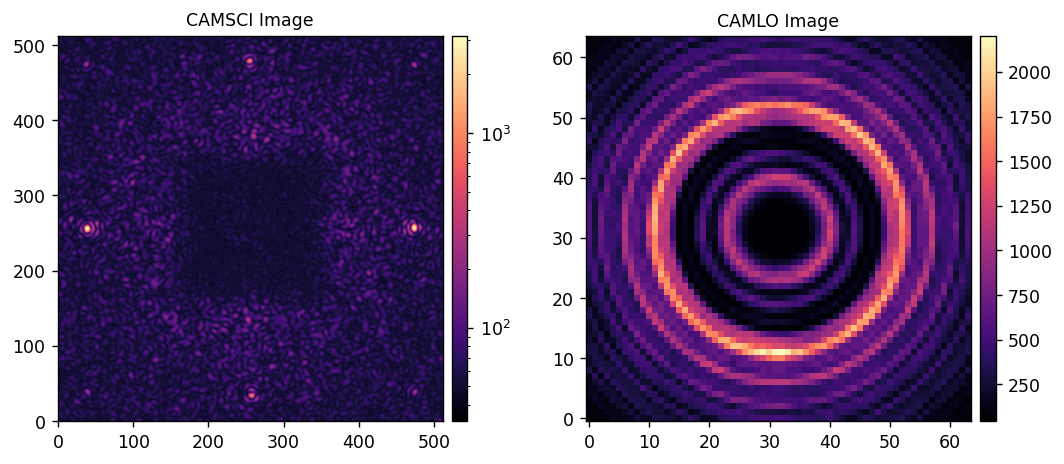

In [3]:
reload(esc)

M = esc.single(
    **model_params,
    entrance_flux=mag0_total_ep_flux,
)
M.load_wfe(model_path)
PREFPM_OPD0 = copy.copy(M.PREFPM_OPD)

M.CAMLO_CAMSCI_FLUX_RATIO = 5

CAMSCI = detector.IMXDETECTOR(
    qe=0.75, 
    gain=0, 
    blacklevel=50, 
    dark_current=0.0025, 
    bits=16,
    exp_time=100e-3,
)
CAMLO = detector.IMXDETECTOR(
    qe=0.75, 
    gain=0, 
    blacklevel=50, 
    dark_current=0.0025, 
    bits=16,
)
M.CAMSCI = CAMSCI
M.CAMLO = CAMLO

M.use_vortex = 1
camsci_im, camlo_im = M.snap_camsci_and_camlo()

utils.imshow(
    [camsci_im, camlo_im],
    titles=['CAMSCI Image', 'CAMLO Image'],
    norms=[LogNorm()],
)



# Test a live process that reads and writes to SHMIMS so we can get live views of the simulated camera images.

In [4]:
shmim_utils.create_shmim('camscisim', (M.ncamsci, M.ncamsci))
shmim_utils.create_shmim('camlosim', (M.ncamlo, M.ncamlo))
shmim_utils.create_shmim('opdsim', (10, 1))
shmim_utils.create_shmim('fsm01', (2, 1))
shmim_utils.create_shmim('fsm02', (2, 1))
shmim_utils.create_shmim('ncamlo', (1,1))
shmim_utils.create_shmim('camscishutter', (1,1))
shmim_utils.create_shmim('camsciexptime', (1,1))
shmim_utils.create_shmim('camscigain', (1,1))
shmim_utils.create_shmim('camloshutter', (1,1))
shmim_utils.create_shmim('camloexptime', (1,1))
shmim_utils.create_shmim('camlogain', (1,1))
shmim_utils.create_shmim('vmag', (1,1))

CAMSCI_STREAM = ImageStream('camscisim')
CAMSCI_SHUTTER_STREAM = ImageStream('camscishutter')
CAMSCI_EXPTIME_STREAM = ImageStream('camsciexptime')
CAMSCI_GAIN_STREAM = ImageStream('camscigain')
CAMLO_STREAM = ImageStream('camlosim')
CAMLO_SHUTTER_STREAM = ImageStream('camloshutter')
CAMLO_EXPTIME_STREAM = ImageStream('camloexptime')
CAMLO_GAIN_STREAM = ImageStream('camlogain')
VMAG_STREAM = ImageStream('vmag')
OPD_STREAM = ImageStream('opdsim')

# FSMT_STREAM = ImageStream('dm17disp')
# DMT_STREAM = ImageStream('dm11disp')
# DM0_STREAM = ImageStream('dm11disp00')

DM_STREAMS = []
for i in range(5):
    shmim_utils.create_shmim(f'dmdisp{i:02}sim', (M.Nact,M.Nact))
    DM_STREAMS.append(ImageStream(f'dmdisp{i:02}sim'))

shmim_utils.create_shmim(f'fsmsim', (2,1))
FSM_STREAM = ImageStream(f'fsmsim')

DM_STREAMS[0].write(ensure_np_array(M.dm_flat))

CAMSCI_EXPTIME_STREAM.write(np.array([[M.CAMSCI.exp_time]]))
CAMLO_EXPTIME_STREAM.write(np.array([[M.CAMLO.exp_time]]))


In [5]:

M.NCAMSCI = 1
M.NCAMLO = 1
wfe_modes = utils.create_zernike_modes(M.APERTURE, nmodes=10, remove_modes=1)

def snap():
    vmag = VMAG_STREAM.grab_latest()[0,0]
    M.flux_scale_factor = 2.512**(-vmag)
    
    wfe_coeff = OPD_STREAM.grab_latest()[0]
    wfe_opd = xp.sum( xp.array(wfe_coeff[:, None, None]) * wfe_modes, axis=0)
    M.set_prefpm_wfe(PREFPM_OPD0 + wfe_opd)

    # fsm_command = FSMT_STREAM.grab_latest().T[0]
    # dm_command = DMT_STREAM.grab_latest() / 1e6
    
    fsm_command = FSM_STREAM.grab_latest()[0]
    M.set_fsm(xp.array(fsm_command), RMS=1)

    total_dm_command = 0.0
    for i in range(5):
        total_dm_command += DM_STREAMS[i].grab_latest()
    M.set_dm(xp.array(total_dm_command), channel=0)

    M.camsci_shutter = CAMSCI_SHUTTER_STREAM.grab_latest()[0,0]>0.5
    M.CAMSCI.exp_time = CAMSCI_EXPTIME_STREAM.grab_latest()[0,0]
    M.CAMSCI.gain = CAMSCI_GAIN_STREAM.grab_latest()[0,0]

    M.camlo_shutter = CAMLO_SHUTTER_STREAM.grab_latest()[0,0]>0.5
    M.CAMLO.exp_time = CAMLO_EXPTIME_STREAM.grab_latest()[0,0]
    M.CAMLO.gain = CAMLO_GAIN_STREAM.grab_latest()[0,0]

    camsci_im, camlo_im = M.snap_camsci_and_camlo()
    
    CAMSCI_STREAM.write(ensure_np_array(camsci_im))
    CAMLO_STREAM.write(ensure_np_array(camlo_im))

In [7]:
%%timeit -n 500
snap()

3.25 ms ± 41.8 μs per loop (mean ± std. dev. of 7 runs, 500 loops each)


In [11]:
cam_freq = 100.0
CYCLETIME = 1/cam_freq

fun_times = []

try:
    print('Running CAMLO simulator continuously ...')
    
    t0 = time.perf_counter()  # Time ref point
    time_counter = 0.0
    
    while 1:
        # snap_camlo_live()
        snap()
        fun_times.append(time.time())
        
        now = time.perf_counter()
        elapsed_time = now - t0
        target_time = time_counter + CYCLETIME
        if elapsed_time < target_time:
            time.sleep(target_time - elapsed_time)

        # In the full program we write to a csv but in this simple program we will just print it
        # milliseconds_since_epoch = datetime.now(timezone.utc)

        time_counter += CYCLETIME
except KeyboardInterrupt:
    fun_times = np.array(fun_times)
    print('CAMLO simulator terminated.')

Running CAMLO simulator continuously ...
CAMLO simulator terminated.


(0.009999941930543519, 100.0005806979369)

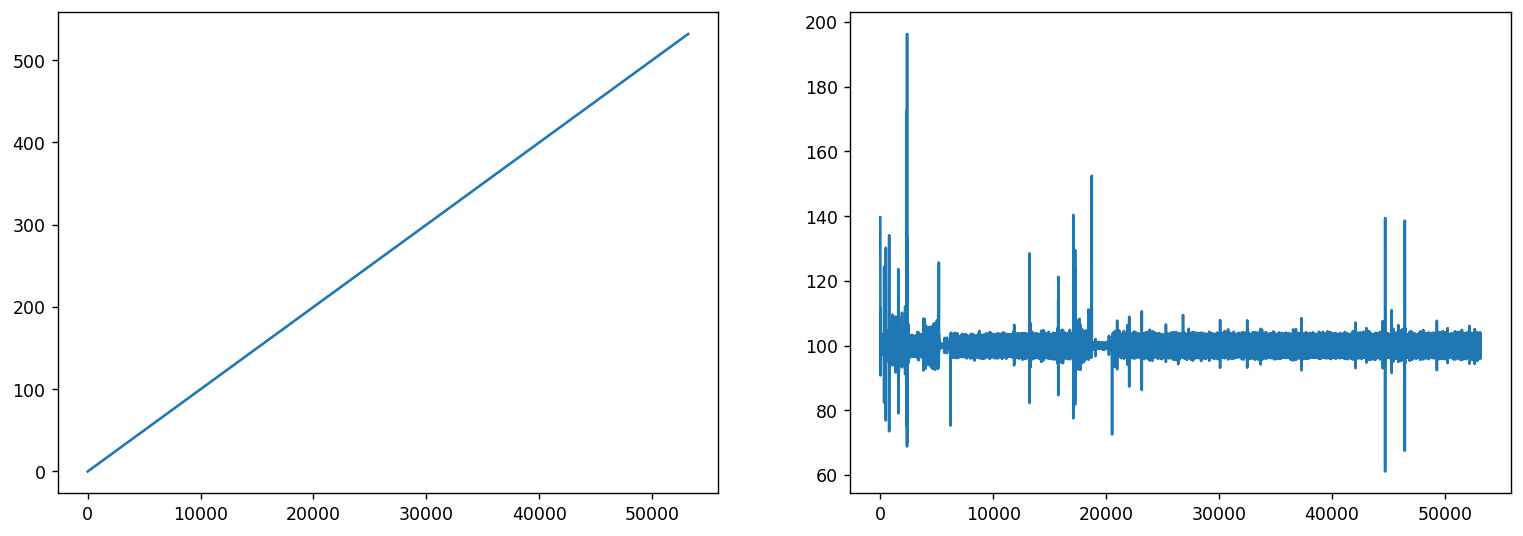

In [9]:

fun_times -= fun_times[0]
del_fun_times = fun_times[1:] - fun_times[:-1]
freqs = 1/del_fun_times
fig, axs = plt.subplots(nrows=1, ncols=2, dpi=125, figsize=(15,5))
axs[0].plot(fun_times)
axs[1].plot(freqs)
np.mean(del_fun_times), 1/np.mean(del_fun_times)

In [ ]:
import multiprocessing

def run_cam_sim(freq):
    cp.cuda.Device(7).use()

    CYCLETIME = 1/freq
    t0 = time.perf_counter()  # Time ref point
    time_counter = 0.0
    
    while True:
        snap()
        # fun_times.append(time.time())
        
        now = time.perf_counter()
        elapsed_time = now - t0
        target_time = time_counter + CYCLETIME
        if elapsed_time < target_time:
            time.sleep(target_time - elapsed_time)

cam_proc = multiprocessing.Process(target=run_cam_sim, args=[10])


In [9]:
cam_proc.start()
print(cam_proc.pid)

1789601


Process Process-2:


Traceback (most recent call last):
  File "/opt/conda/envs/llowfscSim310/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/conda/envs/llowfscSim310/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_1785236/4012377722.py", line 4, in run_cam_sim
    cp.cuda.Device(7).use()
  File "cupy/cuda/device.pyx", line 185, in cupy.cuda.device.Device.use
  File "cupy/cuda/device.pyx", line 191, in cupy.cuda.device.Device.use
  File "cupy_backends/cuda/api/runtime.pyx", line 398, in cupy_backends.cuda.api.runtime.setDevice
  File "cupy_backends/cuda/api/runtime.pyx", line 146, in cupy_backends.cuda.api.runtime.check_status
cupy_backends.cuda.api.runtime.CUDARuntimeError: cudaErrorInitializationError: initialization error


In [10]:
cam_proc.terminate()